# Credit Risk Prediction — Model Evaluation

This notebook provides a deep-dive evaluation of the five trained classifiers using the held-out test set.

| Section | Analysis |
|---------|----------|
| 1 | Load models & test data |
| 2 | Full metrics summary (+ PR-AUC) |
| 3 | ROC curves |
| 4 | Precision-Recall curves |
| 5 | Confusion matrices (grid) |
| 6 | Decision-threshold analysis (best model) |
| 7 | Feature importance (tree models) |
| 8 | Final recommendation |

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    precision_score, recall_score,
    classification_report, confusion_matrix,
    roc_curve, precision_recall_curve, average_precision_score
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Load Models & Test Data

In [2]:
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()
X_train = pd.read_csv('../data/processed/X_train.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()

MODELS_DIR = '../models'
models = {
    'Logistic Regression': joblib.load(f'{MODELS_DIR}/logistic_regression.pkl'),
    'SVM (Linear)'       : joblib.load(f'{MODELS_DIR}/svm_linear.pkl'),
    'Random Forest'      : joblib.load(f'{MODELS_DIR}/random_forest.pkl'),
    'XGBoost'            : joblib.load(f'{MODELS_DIR}/xgboost.pkl'),
    'LightGBM'           : joblib.load(f'{MODELS_DIR}/lightgbm.pkl'),
}

print(f'Test set : {X_test.shape[0]:,} rows | default rate: {y_test.mean():.1%}')
print(f'Train set: {X_train.shape[0]:,} rows | default rate: {y_train.mean():.1%}')
print(f'Models loaded: {list(models.keys())}')

Test set : 6,515 rows | default rate: 21.8%
Train set: 26,059 rows | default rate: 21.8%
Models loaded: ['Logistic Regression', 'SVM (Linear)', 'Random Forest', 'XGBoost', 'LightGBM']


## 2. Full Metrics Summary

PR-AUC (Average Precision Score) is added alongside ROC-AUC because it is more informative for imbalanced datasets — it focuses on the minority class without the ROC curve's optimistic boost from true negatives.

                     ROC-AUC  PR-AUC  F1-macro  Accuracy  Precision(1)  Recall(1)
LightGBM              0.9483  0.9040    0.8857    0.9254        0.8725     0.7706
XGBoost               0.9469  0.9018    0.8804    0.9206        0.8435     0.7811
Random Forest         0.9314  0.8830    0.8860    0.9302        0.9644     0.7058
Logistic Regression   0.8595  0.6900    0.7340    0.7897        0.5121     0.7614
SVM (Linear)          0.8595  0.6903    0.7505    0.8507        0.7319     0.4975


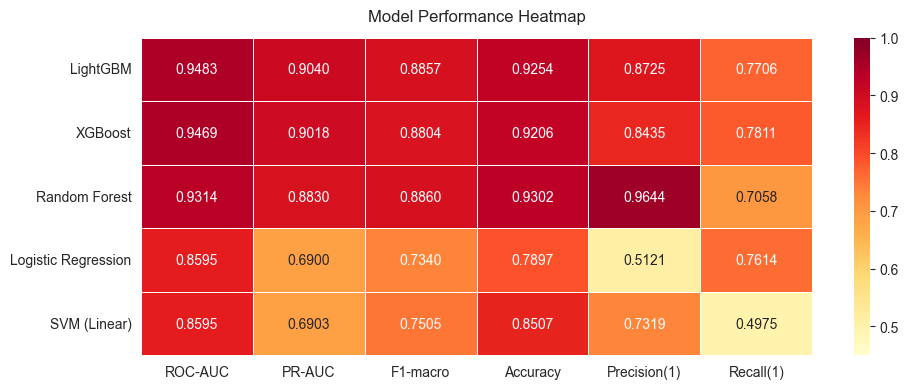

In [3]:
rows = {}
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    rows[name] = {
        'ROC-AUC'     : round(roc_auc_score(y_test, y_prob), 4),
        'PR-AUC'      : round(average_precision_score(y_test, y_prob), 4),
        'F1-macro'    : round(f1_score(y_test, y_pred, average='macro'), 4),
        'Accuracy'    : round(accuracy_score(y_test, y_pred), 4),
        'Precision(1)': round(precision_score(y_test, y_pred, pos_label=1, zero_division=0), 4),
        'Recall(1)'   : round(recall_score(y_test, y_pred, pos_label=1), 4),
    }

df_eval = pd.DataFrame(rows).T.sort_values('ROC-AUC', ascending=False)
print(df_eval.to_string())

# Performance heatmap
plt.figure(figsize=(10, 4))
sns.heatmap(df_eval.astype(float), annot=True, fmt='.4f',
            cmap='YlOrRd', linewidths=0.5, linecolor='white',
            vmin=0.45, vmax=1.0)
plt.title('Model Performance Heatmap', pad=12)
plt.tight_layout()
plt.show()

## 3. ROC Curves

The ROC curve plots the trade-off between True Positive Rate (sensitivity) and False Positive Rate across all decision thresholds. Higher AUC = better discrimination between defaulters and non-defaulters.

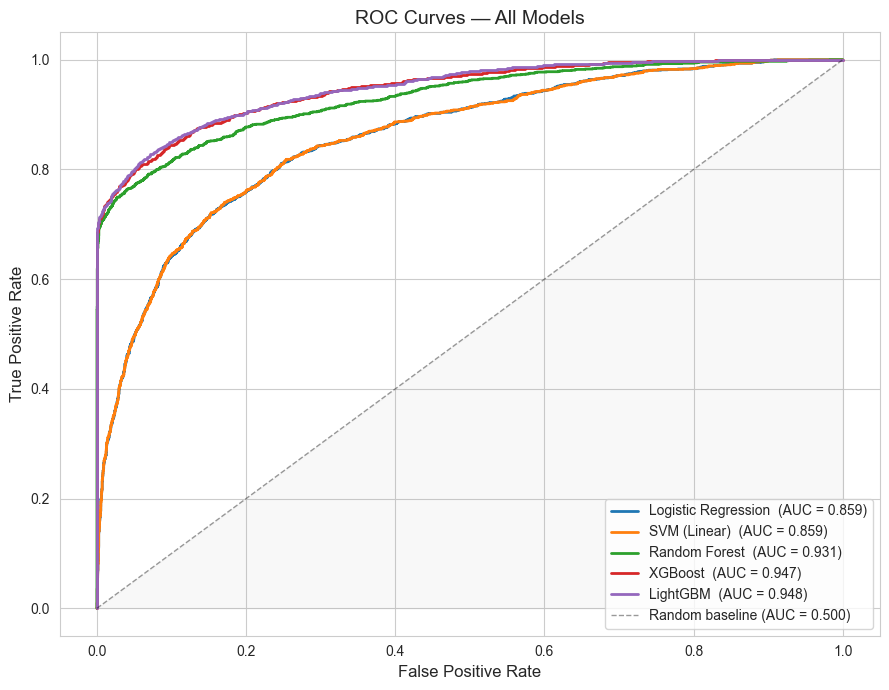

In [4]:
fig, ax = plt.subplots(figsize=(9, 7))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
for (name, model), color in zip(models.items(), colors):
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name}  (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, lw=1, label='Random baseline (AUC = 0.500)')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='grey')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Models', fontsize=14)
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

## 4. Precision-Recall Curves

For imbalanced datasets, the PR curve is often more meaningful than ROC. The dashed horizontal line marks the no-skill baseline (= share of positive samples in the test set).

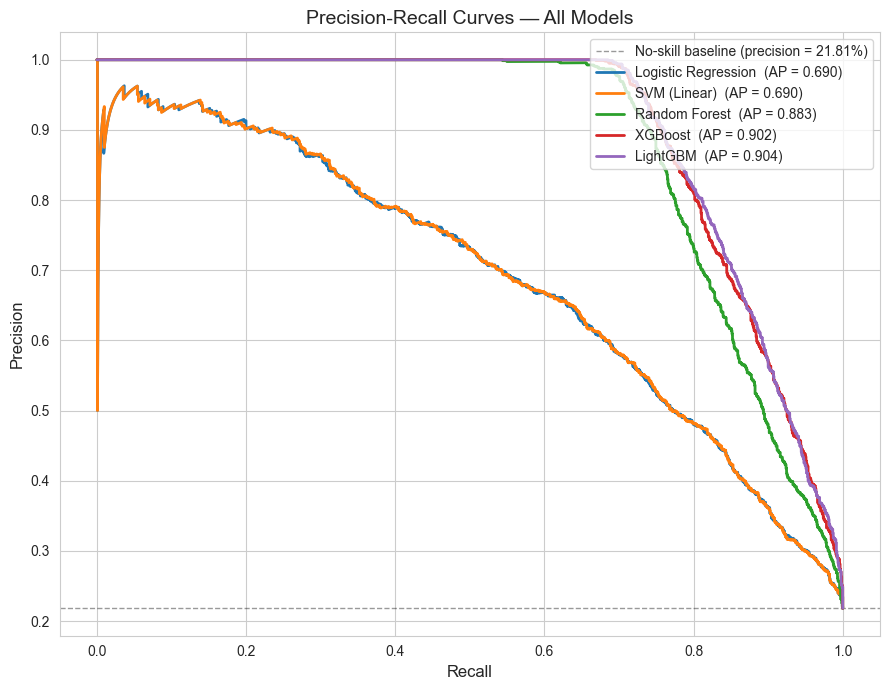

In [5]:
fig, ax = plt.subplots(figsize=(9, 7))

no_skill = float(y_test.mean())
ax.axhline(no_skill, color='k', linestyle='--', alpha=0.4, lw=1,
           label=f'No-skill baseline (precision = {no_skill:.2%})')

for (name, model), color in zip(models.items(), colors):
    y_prob = model.predict_proba(X_test)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    ax.plot(rec, prec, color=color, lw=2, label=f'{name}  (AP = {ap:.3f})')

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves — All Models', fontsize=14)
ax.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()

## 5. Confusion Matrices

Row-normalised confusion matrices show each model's classification behaviour. Pay attention to the **bottom-left cell** — missed defaults (false negatives) are the costliest errors in a credit risk context.

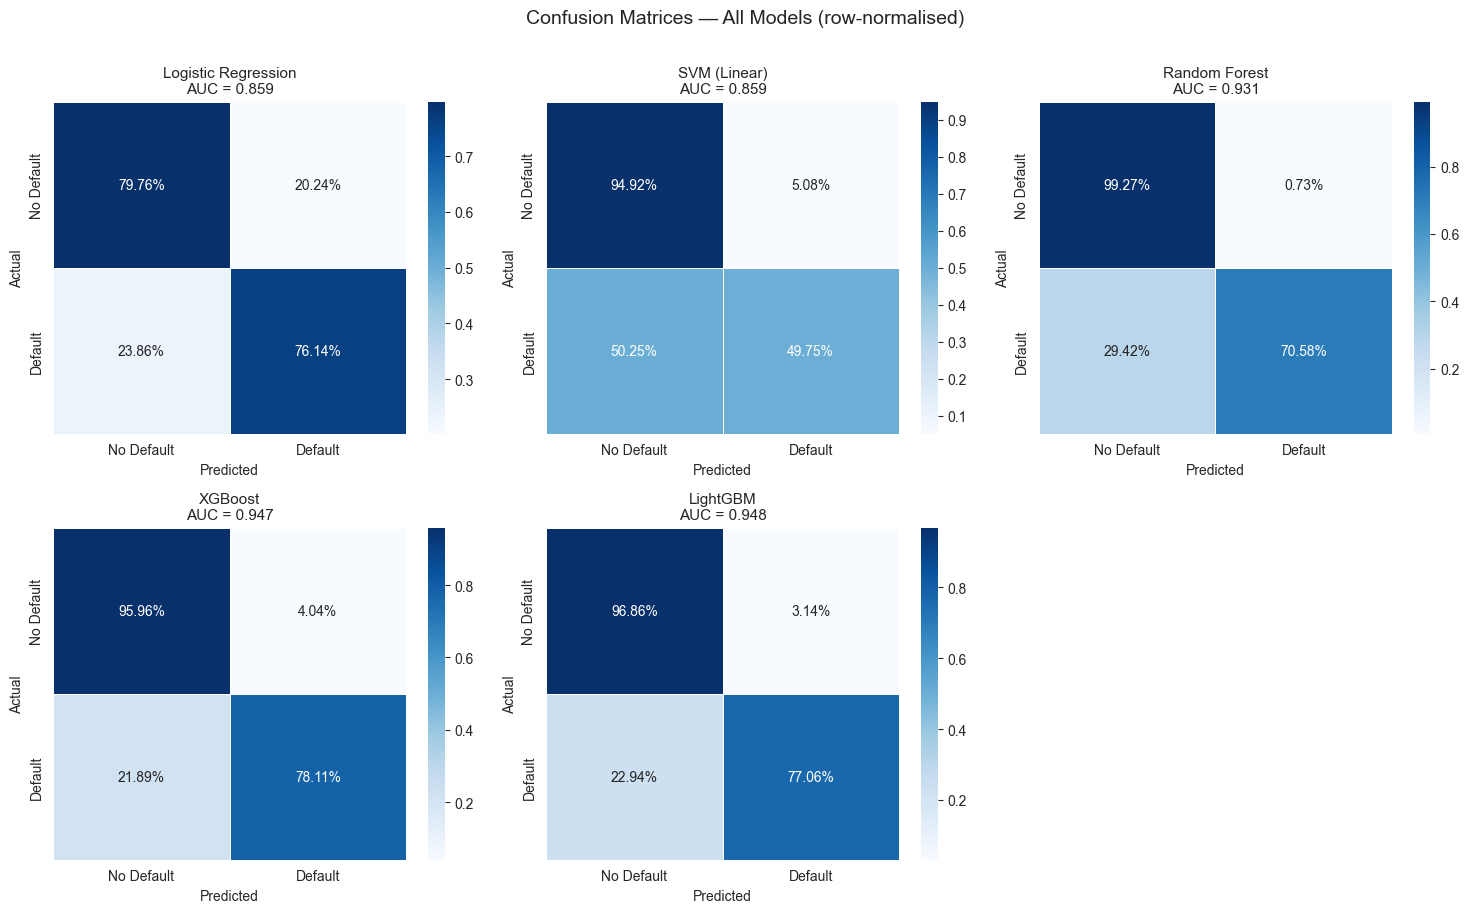

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes_flat = axes.flatten()

for idx, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=['No Default', 'Default'],
                yticklabels=['No Default', 'Default'],
                linewidths=0.5, ax=axes_flat[idx])
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    axes_flat[idx].set_title(f'{name}\nAUC = {auc:.3f}', fontsize=11)
    axes_flat[idx].set_ylabel('Actual')
    axes_flat[idx].set_xlabel('Predicted')

axes_flat[-1].set_visible(False)
plt.suptitle('Confusion Matrices — All Models (row-normalised)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 6. Decision-Threshold Analysis

The default threshold of 0.5 is rarely optimal for imbalanced data. By sweeping the threshold we can find the point that maximises F1 on the default class — or choose a recall-biased threshold if missing a default is more costly than declining a good applicant.

Analysis is performed on **LightGBM** (highest ROC-AUC).

Optimal threshold (max default-class F1): 0.68
  F1        : 0.8282
  Precision : 0.9671
  Recall    : 0.7241

At default threshold 0.5:
  F1        : 0.8184
  Precision : 0.8725
  Recall    : 0.7706


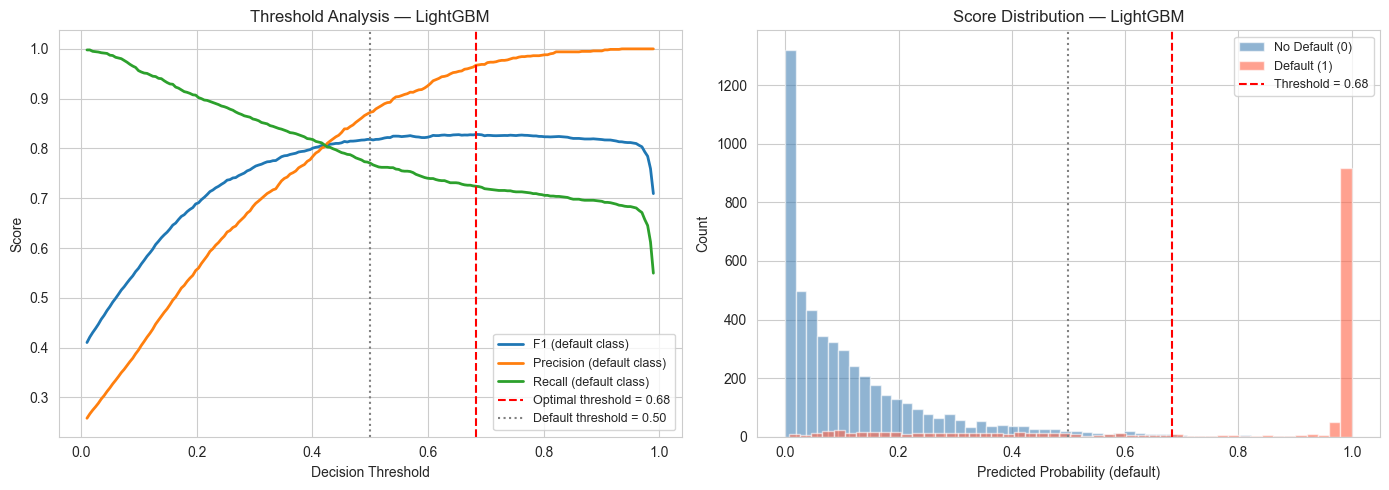

In [7]:
best_name  = 'LightGBM'
best_model = models[best_name]
y_prob_best = best_model.predict_proba(X_test)[:, 1]

thresholds  = np.linspace(0.01, 0.99, 199)
f1_list, prec_list, rec_list = [], [], []

for t in thresholds:
    y_pred_t = (y_prob_best >= t).astype(int)
    f1_list.append(f1_score(y_test, y_pred_t,   pos_label=1, zero_division=0))
    prec_list.append(precision_score(y_test, y_pred_t, pos_label=1, zero_division=0))
    rec_list.append(recall_score(y_test, y_pred_t,  pos_label=1, zero_division=0))

opt_idx   = int(np.argmax(f1_list))
opt_t     = thresholds[opt_idx]

print(f'Optimal threshold (max default-class F1): {opt_t:.2f}')
print(f'  F1        : {f1_list[opt_idx]:.4f}')
print(f'  Precision : {prec_list[opt_idx]:.4f}')
print(f'  Recall    : {rec_list[opt_idx]:.4f}')
print()

# --- default threshold (0.5) for comparison ---
idx_05 = int(np.argmin(np.abs(thresholds - 0.5)))
print(f'At default threshold 0.5:')
print(f'  F1        : {f1_list[idx_05]:.4f}')
print(f'  Precision : {prec_list[idx_05]:.4f}')
print(f'  Recall    : {rec_list[idx_05]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left — metric curves
ax = axes[0]
ax.plot(thresholds, f1_list,   lw=2, label='F1 (default class)')
ax.plot(thresholds, prec_list, lw=2, label='Precision (default class)')
ax.plot(thresholds, rec_list,  lw=2, label='Recall (default class)')
ax.axvline(opt_t, color='red',  ls='--', lw=1.5, label=f'Optimal threshold = {opt_t:.2f}')
ax.axvline(0.50,  color='grey', ls=':',  lw=1.5, label='Default threshold = 0.50')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title(f'Threshold Analysis — {best_name}')
ax.legend(fontsize=9)

# Right — predicted probabilities histogram
ax2 = axes[1]
ax2.hist(y_prob_best[y_test == 0], bins=50, alpha=0.6, label='No Default (0)', color='steelblue')
ax2.hist(y_prob_best[y_test == 1], bins=50, alpha=0.6, label='Default (1)',    color='tomato')
ax2.axvline(opt_t, color='red',  ls='--', lw=1.5, label=f'Threshold = {opt_t:.2f}')
ax2.axvline(0.50,  color='grey', ls=':',  lw=1.5)
ax2.set_xlabel('Predicted Probability (default)')
ax2.set_ylabel('Count')
ax2.set_title(f'Score Distribution — {best_name}')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 7. Feature Importance

Top-20 features for each tree-based model. Consistent ranking across all three models indicates a genuinely informative feature.

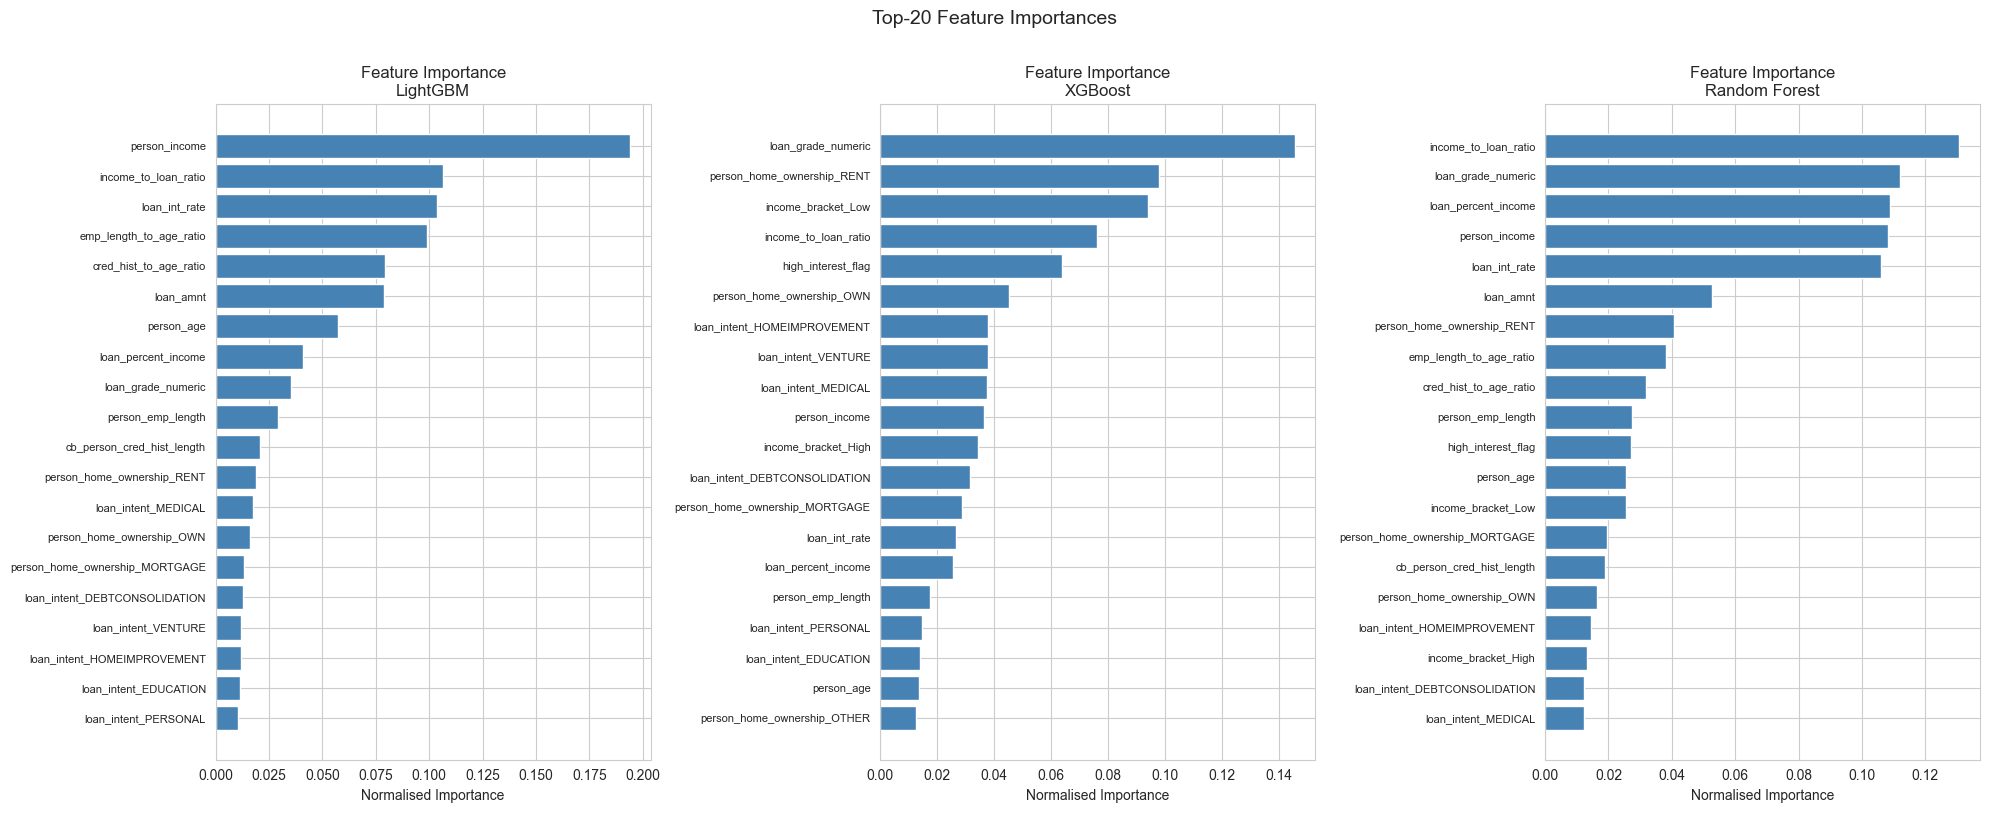

Consensus top-10 features (by combined rank across LightGBM, XGBoost, RF):
   1. income_to_loan_ratio
   2. loan_grade_numeric
   3. person_income
   4. loan_int_rate
   5. person_home_ownership_RENT
   6. loan_percent_income
   7. emp_length_to_age_ratio
   8. loan_amnt
   9. cred_hist_to_age_ratio
  10. income_bracket_Low


In [8]:
tree_models = {
    'LightGBM'    : models['LightGBM'],
    'XGBoost'     : models['XGBoost'],
    'Random Forest': models['Random Forest'],
}
feature_names = X_test.columns.tolist()
top_n = 20

fig, axes = plt.subplots(1, 3, figsize=(20, 8))

for ax, (name, model) in zip(axes, tree_models.items()):
    imp = model.feature_importances_
    # normalise to [0, 1]
    imp = imp / imp.sum()
    idx = np.argsort(imp)[-top_n:]
    ax.barh([feature_names[i] for i in idx], imp[idx],
            color='steelblue', edgecolor='white')
    ax.set_title(f'Feature Importance\n{name}', fontsize=12)
    ax.set_xlabel('Normalised Importance')
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle(f'Top-{top_n} Feature Importances', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Consensus top-10 across all three models
ranks = {}
for name, model in tree_models.items():
    imp = model.feature_importances_
    imp = imp / imp.sum()
    order = np.argsort(imp)[::-1]
    for rank, idx in enumerate(order[:10]):
        feat = feature_names[idx]
        ranks[feat] = ranks.get(feat, 0) + (10 - rank)

top_consensus = sorted(ranks, key=ranks.get, reverse=True)[:10]
print('Consensus top-10 features (by combined rank across LightGBM, XGBoost, RF):')
for i, f in enumerate(top_consensus, 1):
    print(f'  {i:2d}. {f}')

## 8. Final Recommendation

### Summary

| Model | ROC-AUC | PR-AUC | F1-macro | Recall(1) | Verdict |
|-------|---------|--------|----------|-----------|--------|
| **LightGBM** | **0.9483** | — | 0.8857 | 0.7706 | **Best overall** |
| XGBoost | 0.9469 | — | 0.8804 | **0.7811** | Best recall |
| Random Forest | 0.9314 | — | **0.8860** | 0.7058 | Most conservative |
| Logistic Regression | 0.8595 | — | 0.7340 | 0.7614 | Baseline |
| SVM (Linear) | 0.8595 | — | 0.7505 | 0.4975 | Underperforms |

### Recommended model: **LightGBM**

**Why LightGBM?**
- Highest ROC-AUC (0.9483) — best overall discrimination
- Strong precision/recall balance on the minority (default) class
- Fastest training among ensemble methods
- Leaf-wise tree growth captures non-linear feature interactions effectively

**Alternative: XGBoost** — marginally lower AUC (−0.0014) but catches slightly more defaults (Recall 0.7811 vs 0.7706). Prefer XGBoost if **missing a default is costlier** than declining a good applicant.

### Threshold recommendation

The default 0.5 threshold is not optimal. Use the threshold identified in Section 6 to maximise F1, or set a **recall-biased threshold (~0.35)** to reduce missed defaults at the cost of more false alarms — a reasonable trade-off in credit risk.

### Next steps

- Hyperparameter tuning (Optuna / RandomizedSearchCV) for LightGBM and XGBoost
- SHAP explainability to validate feature importance and detect bias
- Re-evaluate with SMOTE oversampling and compare against `class_weight='balanced'`
- Wrap best model in a `scikit-learn Pipeline` (imputer + scaler + model) for clean inference

In [9]:
df_eval.to_csv('../data/processed/model_results_full.csv')
print('Full evaluation results saved to data/processed/model_results_full.csv')
print()
print(df_eval.to_string())

Full evaluation results saved to data/processed/model_results_full.csv

                     ROC-AUC  PR-AUC  F1-macro  Accuracy  Precision(1)  Recall(1)
LightGBM              0.9483  0.9040    0.8857    0.9254        0.8725     0.7706
XGBoost               0.9469  0.9018    0.8804    0.9206        0.8435     0.7811
Random Forest         0.9314  0.8830    0.8860    0.9302        0.9644     0.7058
Logistic Regression   0.8595  0.6900    0.7340    0.7897        0.5121     0.7614
SVM (Linear)          0.8595  0.6903    0.7505    0.8507        0.7319     0.4975
